In [1]:
import msprime
from demography import DemographicTopology
import numpy as np

In [2]:
## Defining Topology
dem = DemographicTopology(['a', 'admix', 'b', 'c'])

dem.add_admixture_event('admix', 'admixPa1', 'admixPa2') # Admixture event: from Admix to Admixpa1 and Admixpa2
dem.add_merge_event('a', 'admixPa1', 'aAdmix')  # Merge event: from A and Admixpa1 to Aadmix
dem.add_merge_event('b', 'admixPa2', 'bAdmix')
dem.add_merge_event('aAdmix', 'bAdmix', 'subAnc')
dem.add_merge_event('subAnc', 'c', 'anc')


[Event 0] Admixture: admix -> admixPa1 & admixPa2
[Event 2] Merge: a & admixPa1 -> aAdmix
[Event 3] Merge: b & admixPa2 -> bAdmix
[Event 4] Merge: aAdmix & bAdmix -> subAnc
[Event 5] Merge: subAnc & c -> anc


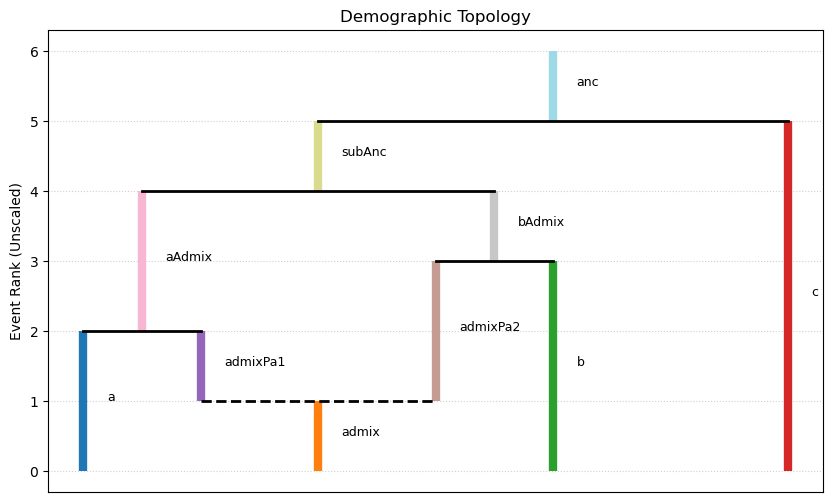

In [3]:
# Under scale = False, you can plot the graph without knowing the parameters. 
dem.plot_demography(scale = False)

In [4]:
# Effective Population Sizes
dem.set_node_ne('a', 3000)
dem.set_node_ne('b', 3000)
dem.set_node_ne('c', 3000)
dem.set_node_ne('admix', 3000)
dem.set_node_ne('admixPa1', 3000)
dem.set_node_ne('admixPa2', 3000)
dem.set_node_ne('aAdmix', 3000)
dem.set_node_ne('bAdmix', 3000)
dem.set_node_ne('subAnc', 3000)
dem.set_node_ne('anc', 3000)

dem.set_admixture_parameters('admix',20, 0.75, 'admixPa1')
dem.set_merge_time('aAdmix', 30)
dem.set_merge_time('bAdmix', 40)
dem.set_merge_time('subAnc',200)
dem.set_merge_time('anc', 500)
dem.finalize_root()

[Finalize] Set anc time_end to infinity.


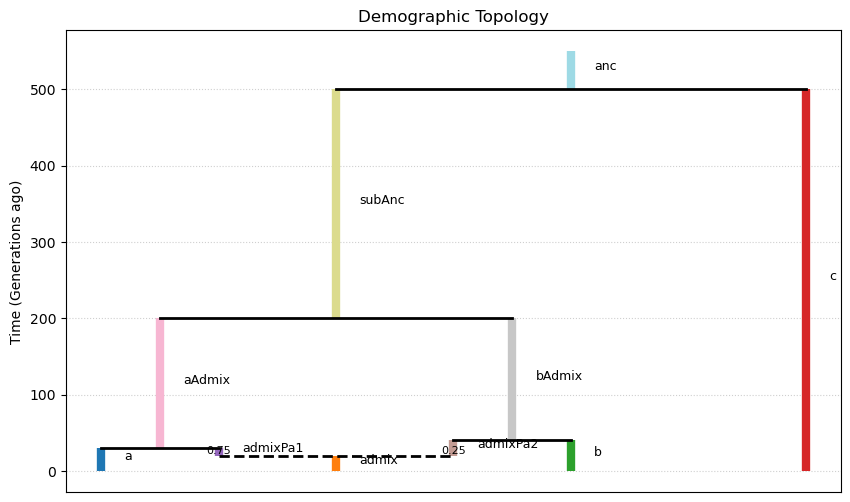

In [5]:
# This plot is sclaed by true time
dem.plot_demography(scale = True)

In [6]:
# For simulation block, first translate to msprime format
from simulation_methods import to_msprime_demography

msp = to_msprime_demography(dem)
msp.debug()

In [7]:
# This block output the pruned snp frequencies table
from simulation_methods import simulate_msprime, simulate_snp_pruning, calculate_ibd_fractions_mrca

# recombination rate set to default 1e-8, thus sequence_length * recombination_rate gives the number of morgans.
mts = simulate_msprime(dem, 
                       sequence_length = 5e6, 
                       recombination_rate = 1e-7, 
                       mutation_rate = 1e-7,
                       samples_per_pop = {'a': 30, 'b': 20, 'c': 10, 'admix': 40})

ids, freq_array = simulate_snp_pruning(
    mts,
    dem,
    temporal_folder = './plink_output',
    cutoff_time = 1000
)


Running: plink --vcf plink_output/snp_ts.vcf --make-bed --out plink_output/snp_ts --double-id --allow-extra-chr --silent
Running: plink --bfile plink_output/snp_ts --indep-pairwise 100 5 0.2 --out plink_output/pruned --allow-extra-chr --silent
LD pruning complete. Kept 1520 SNPs.


In [8]:
bins = [[0.5,0.6],[0.6,0.7],[0.7,0.8],[0.8,0.9],[0.9,1.0],[1.0,1.5],[1.5,2],[2,5],[5,50]]
ibd_mean, ibd_sd = calculate_ibd_fractions_mrca(mts,bins = bins, cm_per_unit=1e-5, num_bootstraps = 2000)

Scanning trees for MRCA segments (19900 pairs)...


In [9]:
from simulation_methods import build_ibd_stan_data

stan_ibd = build_ibd_stan_data(dem, ibd_mean, ibd_sd, bins, T_max = 1000000, cm=50)

[build_ibd_stan_data] Stan data assembled (corrected joint-path model):
  n_leaves     : 4
  n_nodes      : 10
  n_events     : 5
  n_admixture  : 1
  n_leaf_pairs : 10
  n_bins       : 9
  T_max        : 1000000 generations
  ibd_hat      : [0.000e+00, 6.097e-03]
  ibd_se       : [1.000e-08,  1.386e-03]


In [13]:
stan_ibd['admixture_map']

[[0, 1, 4, 5]]

In [21]:
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="ibd_model_Nfixed.stan")

init_dict = {
    "times": [100] * stan_ibd['n_events'],       # reasonable epoch durations
    "admixture_fractions": [0.5] * stan_ibd['n_admixture'],
    "effective_N": 10000.0
}

fit = model.sample(
    data=stan_ibd, 
    chains=4, 
    iter_sampling=4000,
    inits=init_dict,
    show_console=True
)

20:07:34 - cmdstanpy - INFO - Chain [1] start processing
20:07:34 - cmdstanpy - INFO - Chain [2] start processing
20:07:34 - cmdstanpy - INFO - Chain [3] start processing
20:07:34 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 4000
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp7v97_cq7/jk6epmnz.json
Chain [1] init = /var/folders/gm/vzcskl_s

20:09:22 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 5000 / 5000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 23.849 seconds (Warm-up)
Chain [2] 84.296 seconds (Sampling)
Chain [2] 108.145 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [3] Iteration: 4200 / 5000 [ 84%]  (Sampling)
Chain [1] Iteration: 4300 / 5000 [ 86%]  (Sampling)
Chain [4] Iteration: 4900 / 5000 [ 98%]  (Sampling)
Chain [1] Iteration: 4400 / 5000 [ 88%]  (Sampling)
Chain [3] Iteration: 4300 / 5000 [ 86%]  (Sampling)


20:09:26 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 5000 / 5000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 22.915 seconds (Warm-up)
Chain [4] 89.224 seconds (Sampling)
Chain [4] 112.139 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain [3] Iteration: 4400 / 5000 [ 88%]  (Sampling)
Chain [1] Iteration: 4600 / 5000 [ 92%]  (Sampling)
Chain [3] Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain [1] Iteration: 4700 / 5000 [ 94%]  (Sampling)
Chain [3] Iteration: 4600 / 5000 [ 92%]  (Sampling)
Chain [1] Iteration: 4800 / 5000 [ 96%]  (Sampling)
Chain [3] Iteration: 4700 / 5000 [ 94%]  (Sampling)
Chain [1] Iteration: 4900 / 5000 [ 98%]  (Sampling)
Chain [3] Iteration: 4800 / 5000 [ 96%]  (Sampling)


20:09:41 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 5000 / 5000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 25.585 seconds (Warm-up)
Chain [1] 101.488 seconds (Sampling)
Chain [1] 127.073 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 4900 / 5000 [ 98%]  (Sampling)


20:09:44 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 5000 / 5000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 23.981 seconds (Warm-up)
Chain [3] 106.009 seconds (Sampling)
Chain [3] 129.99 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 


In [22]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,6.354520e+02,4.704980e-02,2.253160e+00,2.053480e+00,6.311020e+02,6.358940e+02,6.383100e+02,2787.10,2996.440,7.31490,1.00064
times[1],1.655160e+01,9.350290e-02,7.309500e+00,8.288540e+00,3.744510e+00,1.710000e+01,2.758450e+01,5848.40,4251.190,15.34950,1.00110
times[2],1.413990e+01,9.868140e-02,7.625690e+00,8.744260e+00,2.813080e+00,1.348950e+01,2.746580e+01,5767.68,5956.360,15.13760,1.00060
times[3],2.191080e+01,1.509910e-01,1.051370e+01,1.080420e+01,5.489380e+00,2.133200e+01,4.018930e+01,4608.91,4194.070,12.09630,1.00047
times[4],1.274350e+02,1.369640e-01,1.019620e+01,1.028440e+01,1.097000e+02,1.280300e+02,1.430970e+02,5481.71,7374.920,14.38710,1.00050
...,...,...,...,...,...,...,...,...,...,...,...
"ibd_number[9,3,4]",1.215170e-40,3.089600e-42,3.645870e-40,1.992610e-41,2.186410e-46,1.345310e-41,5.836100e-40,2468.15,851.897,6.47779,1.00230
"ibd_number[9,4,1]",1.215170e-40,3.089600e-42,3.645870e-40,1.992610e-41,2.186410e-46,1.345310e-41,5.836100e-40,2468.15,851.897,6.47779,1.00230
"ibd_number[9,4,2]",1.215170e-40,3.089600e-42,3.645870e-40,1.992610e-41,2.186410e-46,1.345310e-41,5.836100e-40,2468.15,851.897,6.47779,1.00230
"ibd_number[9,4,3]",1.215170e-40,3.089600e-42,3.645870e-40,1.992610e-41,2.186410e-46,1.345310e-41,5.836100e-40,2468.15,851.897,6.47779,1.00230


In [23]:
np.mean(fit.admixture_fractions)

np.float64(0.7611267032918749)

In [25]:
np.mean(fit.effective_N)

np.float64(5951.57164231875)

In [72]:
from inference_methods import calculate_treemix_covariance

w_hat, w_se = calculate_treemix_covariance(
    freq_array,
    min_maf = 0.05,
    block_size_snps = 400
)

In [65]:
cm_values = [10, 30, 50, 100, 150, 200, 250, 300]
fits = {}
model = CmdStanModel(stan_file="ibd_model_Nfixed.stan")
 
for cm_val in cm_values:
    print(f"Running cm = {cm_val}...")

    mts = simulate_msprime(dem, 
                       sequence_length = cm_val * 1e4, 
                       recombination_rate = 1e-6, 
                       mutation_rate = 1e-6,
                       samples_per_pop = {'a': 20, 'b': 20, 'c': 20, 'admix': 20})
    bins = [[0.5,0.6],[0.6,0.7],[0.7,0.8],[0.8,0.9],[0.9,1.0],[1.0,1.5],[1.5,2],[2,5],[5,cm_val]]
    ibd_mean, ibd_sd = calculate_ibd_fractions_mrca(mts,bins = bins, cm_per_unit=1e-4, num_bootstraps = 2000)
    
    init_dict = {
    "times": [100] * stan_ibd['n_events'],       
    "admixture_fractions": [0.5] * stan_ibd['n_admixture'],
    "effective_N": 10000.0
    }
    stan_ibd = build_ibd_stan_data(dem, ibd_mean, ibd_sd, bins, T_max = 1000000, cm=cm_val)

    fit = model.sample(
        data=stan_ibd, 
        chains=4,
        iter_warmup = 2000, 
        iter_sampling=4000,
        adapt_delta = 0.95,
        inits=init_dict,
        show_console=True
        )
    fits[cm_val] = fit


10:59:20 - cmdstanpy - INFO - compiling stan file /Users/qichen/github/admix_stan/new_pipeline/ibd_model_Nfixed.stan to exe file /Users/qichen/github/admix_stan/new_pipeline/ibd_model_Nfixed
10:59:32 - cmdstanpy - INFO - compiled model executable: /Users/qichen/github/admix_stan/new_pipeline/ibd_model_Nfixed


Running cm = 10...
Scanning trees for MRCA segments (12720 pairs)...
[build_ibd_stan_data] Stan data assembled (corrected joint-path model):
  n_leaves     : 4
  n_nodes      : 10
  n_events     : 5
  n_admixture  : 1
  n_leaf_pairs : 10
  n_bins       : 9
  T_max        : 1000000 generations
  ibd_hat      : [0.000e+00, 1.011e-02]
  ibd_se       : [1.000e-08,  2.212e-03]


11:00:09 - cmdstanpy - INFO - Chain [1] start processing
11:00:09 - cmdstanpy - INFO - Chain [2] start processing
11:00:09 - cmdstanpy - INFO - Chain [3] start processing
11:00:09 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 4000
Chain [1] num_warmup = 2000
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.95
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp7v97_cq7/p0b1d091.json
Chain [1] init = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h000

11:02:08 - cmdstanpy - INFO - Chain [3] done processing


...

Chain [4] Iteration: 5900 / 6000 [ 98%]  (Sampling)
Chain [1] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 71.515 seconds (Warm-up)
Chain [1] 112.121 seconds (Sampling)
Chain [1] 183.636 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 


12:43:49 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 64.111 seconds (Warm-up)
Chain [4] 122.54 seconds (Sampling)
Chain [4] 186.651 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 4800 / 6000 [ 80%]  (Sampling)
Chain [3] Iteration: 4900 / 6000 [ 81%]  (Sampling)
Chain [3] Iteration: 5000 / 6000 [ 83%]  (Sampling)
Chain [3] Iteration: 5100 / 6000 [ 85%]  (Sampling)
Chain [3] Iteration: 5200 / 6000 [ 86%]  (Sampling)
Chain [3] Iteration: 5300 / 6000 [ 88%]  (Sampling)
Chain [3] Iteration: 5400 / 6000 [ 90%]  (Sampling)
Chain [3] Iteration: 5500 / 6000 [ 91%]  (Sampling)
Chain [3] Iteration: 5600 / 6000 [ 93%]  (Sampling)
Chain [3] Iteration: 5700 / 6000 [ 95%]  (Sampling)
Chain [3] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [3] Iteration: 5900 / 6000 [ 98%]  (Sampling)


12:44:34 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 78.406 seconds (Warm-up)
Chain [3] 152.665 seconds (Sampling)
Chain [3] 231.071 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 


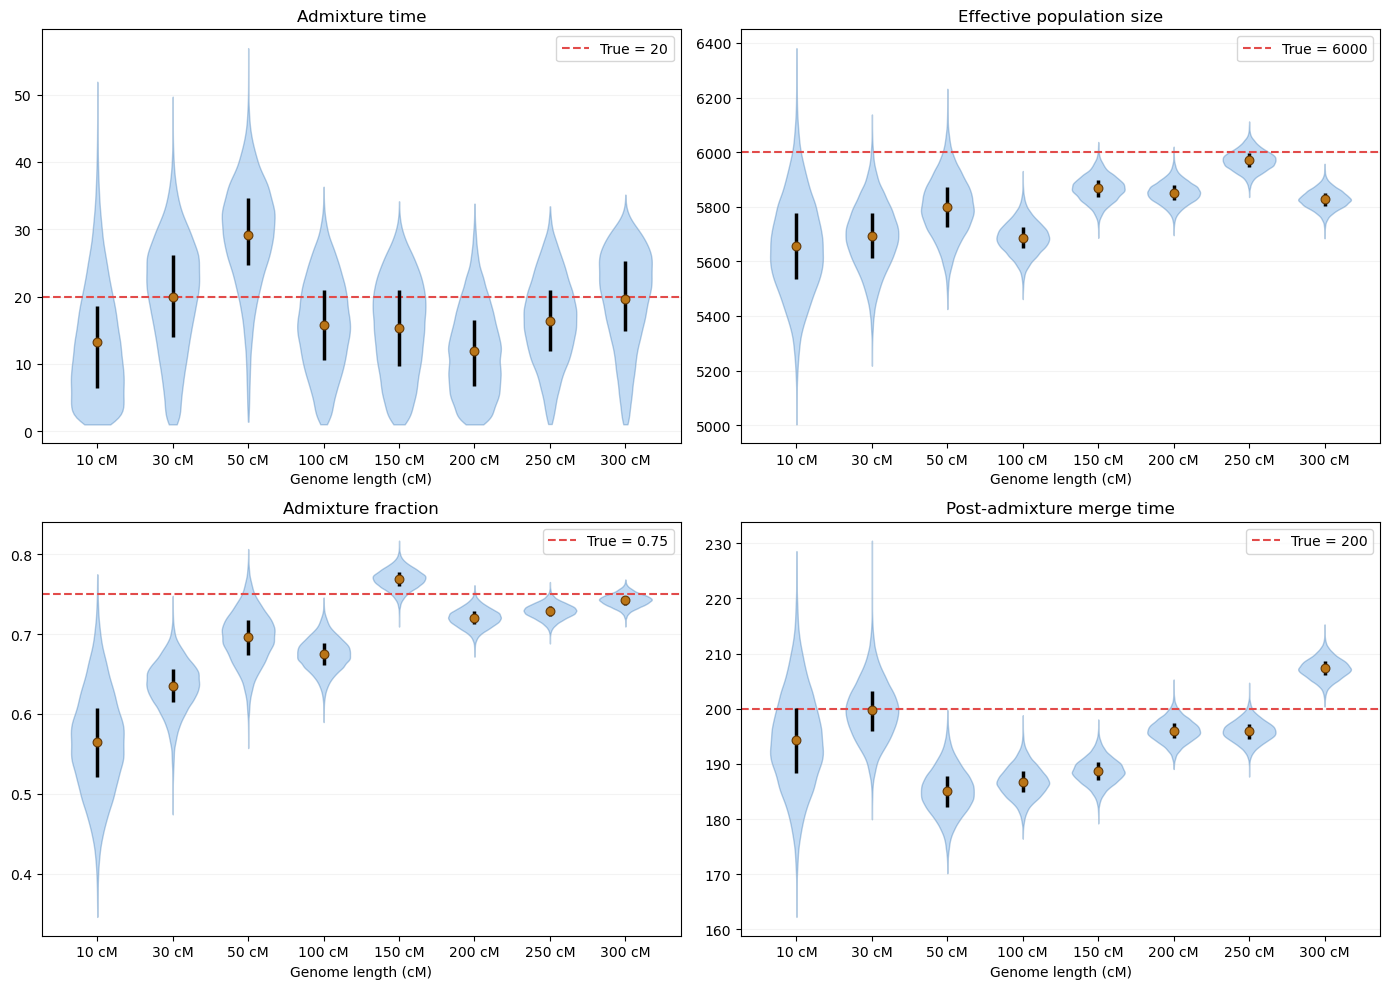

In [66]:
import matplotlib.pyplot as plt

# True values — fill these in
true_vals = {
    "Admixture time": 20,
    "Effective population size": 6000,
    "Admixture fraction": 0.75,
    "Post-admixture merge time": 200,
}
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
for ax, (name, tv) in zip(axes.flatten(), true_vals.items()):
    samples_list = []
 
    for cm_val in cm_values:
        fit = fits[cm_val]
 
        if name == "Admixture time":
            s = fit.stan_variable("times")[:, 0]
        elif name == "Effective population size":
            s = fit.stan_variable("effective_N")
        elif name == "Admixture fraction":
            af = fit.stan_variable("admixture_fractions")
            s = af if af.ndim == 1 else af[:, 0]
        else:
            s = np.sum(fit.stan_variable("times")[:, 0:4], axis=1)
 
        samples_list.append(s)
 
    parts = ax.violinplot(samples_list, positions=range(len(cm_values)),
                          showmeans=False, showextrema=False, widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor("#378ADD")
        pc.set_alpha(0.3)
        pc.set_edgecolor("#185FA5")
 
    for i, s in enumerate(samples_list):
        q25, q75 = np.percentile(s, [25, 75])
        ax.vlines(i, q25, q75, color="k", linewidth=2.5, zorder=3)
        ax.scatter(i, np.mean(s), color="#BA7517", s=40, zorder=4,
                   edgecolors="#633806", linewidths=0.8)
 
    ax.axhline(tv, color="#E24B4A", ls="--", lw=1.5, label=f"True = {tv}")
    ax.legend(fontsize=10)
    ax.set_xticks(range(len(cm_values)))
    ax.set_xticklabels([f"{cm} cM" for cm in cm_values])
    ax.set_xlabel("Genome length (cM)")
    ax.set_title(name)
    ax.grid(axis="y", alpha=0.15)
 
plt.tight_layout()
plt.savefig("posterior_convergence.png", dpi=200, bbox_inches="tight")
plt.show()

In [64]:
cm_values = [10, 30, 50, 100, 150, 200, 250, 300]
fits = {}
model = CmdStanModel(stan_file="ibd_model_Nfixed.stan")
 
for cm_val in cm_values:
    print(f"Running cm = {cm_val}...")

    mts = simulate_msprime(dem, 
                       sequence_length = cm_val * 1e4, 
                       recombination_rate = 1e-6, 
                       mutation_rate = 1e-6,
                       samples_per_pop = {'a': 20, 'b': 20, 'c': 20, 'admix': 20})
    bins = [[0.5,0.6],[0.6,0.7],[0.7,0.8],[0.8,0.9],[0.9,1.0],[1.0,1.5],[1.5,2],[2,5],[5,cm_val]]
    ibd_mean, ibd_sd = calculate_ibd_fractions_mrca(mts,bins = bins, cm_per_unit=1e-4, num_bootstraps = 2000)
    
    init_dict = {
    "times": [100] * stan_ibd['n_events'],       
    "admixture_fractions": [0.5] * stan_ibd['n_admixture'],
    "effective_N": 10000.0
    }
    stan_ibd = build_ibd_stan_data(dem, ibd_mean, ibd_sd, bins, T_max = 100000, cm=cm_val)

    fit = model.pathfinder(
        data=stan_ibd,
        inits=init_dict,
        show_console=True
    )
    fits[cm_val] = fit

10:40:13 - cmdstanpy - INFO - compiling stan file /Users/qichen/github/admix_stan/new_pipeline/ibd_model_Nfixed.stan to exe file /Users/qichen/github/admix_stan/new_pipeline/ibd_model_Nfixed
10:40:25 - cmdstanpy - INFO - compiled model executable: /Users/qichen/github/admix_stan/new_pipeline/ibd_model_Nfixed


Running cm = 10...
Scanning trees for MRCA segments (12720 pairs)...
[build_ibd_stan_data] Stan data assembled (corrected joint-path model):
  n_leaves     : 4
  n_nodes      : 10
  n_events     : 5
  n_admixture  : 1
  n_leaf_pairs : 10
  n_bins       : 9
  T_max        : 100000 generations
  ibd_hat      : [0.000e+00, 1.011e-02]
  ibd_se       : [1.000e-08,  2.292e-03]


10:41:01 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = pathfinder
Chain [1] pathfinder
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] num_psis_draws = 1000 (Default)
Chain [1] num_paths = 4 (Default)
Chain [1] save_single_paths = false (Default)
Chain [1] psis_resample = true (Default)
Chain [1] calculate_lp = true (Default)
Chain [1] max_lbfgs_iters = 1000 (Default)
Chain [1] num_draws = 1000 (Default)
Chain [1] num_elbo_draws = 25 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp7v97_cq7/4gd8iczn.json
Chain [1] init = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp7v97_cq7/8daw68j9.json
Chain [1] random
Chain [1] seed = 98052
Chain [1] output
Chain [1] file = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp7v97_c

10:41:02 - cmdstanpy - INFO - Chain [1] done processing


...

10:52:43 - cmdstanpy - INFO - Chain [1] start processing


[build_ibd_stan_data] Stan data assembled (corrected joint-path model):
  n_leaves     : 4
  n_nodes      : 10
  n_events     : 5
  n_admixture  : 1
  n_leaf_pairs : 10
  n_bins       : 9
  T_max        : 100000 generations
  ibd_hat      : [0.000e+00, 5.851e-03]
  ibd_se       : [1.000e-08,  1.230e-03]
Chain [1] method = pathfinder
Chain [1] pathfinder
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] num_psis_draws = 1000 (Default)
Chain [1] num_paths = 4 (Default)
Chain [1] save_single_paths = false (Default)
Chain [1] psis_resample = true (Default)
Chain [1] calculate_lp = true (Default)
Chain [1] max_lbfgs_iters = 1000 (Default)
Chain [1] num_draws = 1000 (Default)
Chain [1] num_elbo_draws = 25 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] f

10:52:44 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Pareto k value (0.99) is greater than 0.7. Importance resampling was not able to improve the approximation, which may indicate that the approximation itself is poor.
Chain [1] 
Running cm = 150...
Scanning trees for MRCA segments (12720 pairs)...
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/miniconda3/envs/genetics_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/ipykernel_54728/2844287346.py", line 14, in <module>
    ibd_mean, ibd_sd = calculate_ibd_fractions_mrca(mts,bins = bins, cm_per_unit=1e-4, num_bootstraps = 2000)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/qichen/github/admix_stan/new_pipeline/simulation_methods.py", line None, in calculate_ibd_fractions_mrca
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/genetics_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 2194, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^

In [ ]:
true_vals = {
    "Admixture time": 20,
    "Effective population size": 6000,
    "Admixture fraction": 0.75,
    "Post-admixture merge time": 200,
}
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
for ax, (name, tv) in zip(axes.flatten(), true_vals.items()):
    samples_list = []
 
    for cm_val in cm_values:
        fit = fits[cm_val]
 
        if name == "Admixture time":
            s = fit.stan_variable("times")[:, 0]
        elif name == "Effective population size":
            s = fit.stan_variable("effective_N")
        elif name == "Admixture fraction":
            af = fit.stan_variable("admixture_fractions")
            s = af if af.ndim == 1 else af[:, 0]
        else:
            s = np.sum(fit.stan_variable("times")[:, 0:4], axis=1)
 
        samples_list.append(s)
 
    parts = ax.violinplot(samples_list, positions=range(len(cm_values)),
                          showmeans=False, showextrema=False, widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor("#378ADD")
        pc.set_alpha(0.3)
        pc.set_edgecolor("#185FA5")
 
    for i, s in enumerate(samples_list):
        q25, q75 = np.percentile(s, [25, 75])
        ax.vlines(i, q25, q75, color="k", linewidth=2.5, zorder=3)
        ax.scatter(i, np.mean(s), color="#BA7517", s=40, zorder=4,
                   edgecolors="#633806", linewidths=0.8)
 
    ax.axhline(tv, color="#E24B4A", ls="--", lw=1.5, label=f"True = {tv}")
    ax.legend(fontsize=10)
    ax.set_xticks(range(len(cm_values)))
    ax.set_xticklabels([f"{cm} cM" for cm in cm_values])
    ax.set_xlabel("Genome length (cM)")
    ax.set_title(name)
    ax.grid(axis="y", alpha=0.15)
 
plt.tight_layout()
plt.savefig("posterior_convergence.png", dpi=200, bbox_inches="tight")
plt.show()